# Deep Learning Assignment – AG News Text Classification

## RNN vs LSTM vs GRU

**Objective:** Develop and compare Simple RNN, LSTM, and GRU models for multi-class sequence classification using the **AG News dataset**.

### Dataset Classes
- **0 – World**
- **1 – Sports**
- **2 – Business**
- **3 – Sci/Tech**

### Models Compared
1. Simple RNN
2. LSTM
3. GRU

### Evaluation
The models are compared using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Training time
- Number of parameters
- Training/validation curves

> **Note:** The notebook downloads the official AG News CSV files automatically, so a separate manual dataset upload is not required.


## 1. Install Required Libraries

Run this cell if the required packages are not already installed.

In [1]:
# Uncomment if packages are not installed
# !pip install tensorflow pandas numpy matplotlib seaborn scikit-learn

# For a standard environment, the packages below are sufficient:
# TensorFlow, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn


## 2. Import Libraries

In [2]:
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Dropout,
    Dense
)
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))


TensorFlow version: 2.21.0
Num GPUs Available: 0


## 3. Dataset Description

The AG News dataset is a well-known benchmark for **multi-class text classification**.

It contains:
- **120,000 training samples**
- **7,600 test samples**
- **4 balanced news categories**

Each record contains a news title and description. We combine these two fields into a single input sequence.

The dataset is suitable for RNN, LSTM, and GRU because the input is natural language and word order provides useful sequential information.


## 4. Load the AG News Dataset

In [3]:
# Official CSV locations used by the PyTorch AG News dataset loader
TRAIN_URL = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"
TEST_URL  = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv"

column_names = ["label", "title", "description"]

train_df = pd.read_csv(TRAIN_URL, header=None, names=column_names)
test_df = pd.read_csv(TEST_URL, header=None, names=column_names)

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

display(train_df.head())


Training shape: (120000, 3)
Testing shape : (7600, 3)


,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


## 5. Basic Dataset Exploration

Training samples: 120000
Testing samples : 7600

Missing values:
label          0
title          0
description    0
category       0
dtype: int64

Class distribution:
category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


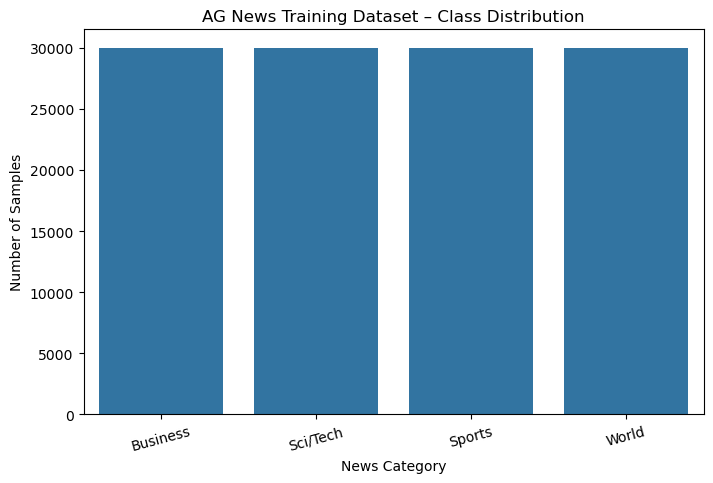

In [4]:
class_names = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

train_df["category"] = train_df["label"].map(class_names)
test_df["category"] = test_df["label"].map(class_names)

print("Training samples:", len(train_df))
print("Testing samples :", len(test_df))
print("\nMissing values:")
print(train_df.isnull().sum())

print("\nClass distribution:")
print(train_df["category"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x="category", order=train_df["category"].value_counts().index)
plt.title("AG News Training Dataset – Class Distribution")
plt.xlabel("News Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=15)
plt.show()


## 6. Prepare Text and Labels

The title and description are combined to provide the model with more contextual information.

Labels are converted from:
- 1 → World
- 2 → Sports
- 3 → Business
- 4 → Sci/Tech

to:
- 0 → World
- 1 → Sports
- 2 → Business
- 3 → Sci/Tech


In [5]:
# Combine title and description
train_df["text"] = train_df["title"].fillna("") + " " + train_df["description"].fillna("")
test_df["text"] = test_df["title"].fillna("") + " " + test_df["description"].fillna("")

# Convert labels from 1–4 to 0–3
label_map = {1: 0, 2: 1, 3: 2, 4: 3}

y_full = train_df["label"].map(label_map).astype(int).values
y_test = test_df["label"].map(label_map).astype(int).values

X_full = train_df["text"].values
X_test = test_df["text"].values

print("Example text:")
print(X_full[0])
print("\nEncoded label:", y_full[0])


Example text:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Encoded label: 2


## 7. Text Preprocessing

In [6]:
def clean_text(text):
    """Basic text cleaning while preserving word order."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # Remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)          # Keep letters and spaces
    text = re.sub(r"\s+", " ", text).strip()       # Remove extra spaces
    return text

X_full_clean = np.array([clean_text(text) for text in X_full])
X_test_clean = np.array([clean_text(text) for text in X_test])

print("Before cleaning:")
print(X_full[0])

print("\nAfter cleaning:")
print(X_full_clean[0])


Before cleaning:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

After cleaning:
wall st bears claw back into the black reuters reuters short sellers wall street s dwindling band of ultra cynics are seeing green again


## 8. Train–Validation Split

In [7]:
# 80% training and 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_full_clean,
    y_full,
    test_size=0.20,
    random_state=42,
    stratify=y_full
)

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples   :", len(X_test_clean))


Training samples  : 96000
Validation samples: 24000
Testing samples   : 7600


## 9. Tokenization and Sequence Padding

The tokenizer is fitted **only on the training data** to avoid information leakage.

A vocabulary limit and maximum sequence length are used to keep the models computationally manageable.


In [8]:
VOCAB_LIMIT = 20000
MAX_LEN = 60
EMBEDDING_DIM = 64
RNN_UNITS = 64
BATCH_SIZE = 128
EPOCHS = 8

tokenizer = Tokenizer(num_words=VOCAB_LIMIT, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

VOCAB_SIZE = min(VOCAB_LIMIT, len(tokenizer.word_index) + 1)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print("Vocabulary size:", VOCAB_SIZE)
print("Training shape :", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Testing shape  :", X_test_pad.shape)


Vocabulary size: 20000
Training shape : (96000, 60)
Validation shape: (24000, 60)
Testing shape  : (7600, 60)


## 10. Majority-Class Baseline

Before training neural networks, we establish a simple baseline.

Because AG News has four balanced classes, a majority-class classifier is expected to achieve approximately **25% accuracy**. The RNN, LSTM, and GRU should significantly outperform this baseline.


In [9]:
majority_class = pd.Series(y_train).value_counts().idxmax()
baseline_predictions = np.full_like(y_test, majority_class)

baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_precision = precision_score(
    y_test, baseline_predictions, average="macro", zero_division=0
)
baseline_recall = recall_score(
    y_test, baseline_predictions, average="macro", zero_division=0
)
baseline_f1 = f1_score(
    y_test, baseline_predictions, average="macro", zero_division=0
)

print("Majority class:", majority_class)
print(f"Baseline Accuracy : {baseline_accuracy:.4f}")
print(f"Baseline Precision: {baseline_precision:.4f}")
print(f"Baseline Recall   : {baseline_recall:.4f}")
print(f"Baseline F1-score : {baseline_f1:.4f}")


Majority class: 1
Baseline Accuracy : 0.2500
Baseline Precision: 0.0625
Baseline Recall   : 0.2500
Baseline F1-score : 0.1000


## 11. Common Training Configuration

In [10]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

def compile_model(model):
    """Compile a multi-class sequence classification model."""
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


## 12. Model 1 — Simple RNN

### Architecture
Embedding → SimpleRNN → Dropout → Dense

The Simple RNN processes the sequence one time step at a time. It provides a useful baseline for comparing more advanced recurrent architectures.


In [11]:
rnn_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    SimpleRNN(RNN_UNITS),
    Dropout(0.30),
    Dense(4, activation="softmax")
])

rnn_model = compile_model(rnn_model)
rnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,516 (4.92 MB)

 Trainable params: 1,288,516 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

## 13. Train the Simple RNN

In [12]:
start_time = time.time()

rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

rnn_time = time.time() - start_time
print(f"Simple RNN training time: {rnn_time:.2f} seconds")


Epoch 1/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.7721 - loss: 0.5714 - val_accuracy: 0.8900 - val_loss: 0.3498
Epoch 2/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9067 - loss: 0.3105 - val_accuracy: 0.8895 - val_loss: 0.3604
Epoch 3/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9244 - loss: 0.2582 - val_accuracy: 0.8900 - val_loss: 0.3424
Epoch 4/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9372 - loss: 0.2178 - val_accuracy: 0.8987 - val_loss: 0.3395
Epoch 5/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9439 - loss: 0.1973 - val_accuracy: 0.8870 - val_loss: 0.3866
Epoch 6/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9496 - loss: 0.1773 - val_accuracy: 0.8919 - val_loss: 0.3690
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 4.
Simple RNN training time: 95.59 seconds


## 14. Model 2 — LSTM

### Architecture
Embedding → LSTM → Dropout → Dense

LSTM introduces gated memory mechanisms that help preserve useful information over longer sequences and reduce the vanishing-gradient problem associated with basic RNNs.


In [13]:
lstm_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    LSTM(RNN_UNITS),
    Dropout(0.30),
    Dense(4, activation="softmax")
])

lstm_model = compile_model(lstm_model)
lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 60, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,284 (5.01 MB)

 Trainable params: 1,313,284 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

## 15. Train the LSTM

In [14]:
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

lstm_time = time.time() - start_time
print(f"LSTM training time: {lstm_time:.2f} seconds")


Epoch 1/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.7550 - loss: 0.5882 - val_accuracy: 0.9044 - val_loss: 0.3126
Epoch 2/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.9190 - loss: 0.2668 - val_accuracy: 0.9165 - val_loss: 0.2679
Epoch 3/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - accuracy: 0.9376 - loss: 0.2102 - val_accuracy: 0.9188 - val_loss: 0.2860
Epoch 4/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - accuracy: 0.9469 - loss: 0.1801 - val_accuracy: 0.9115 - val_loss: 0.2811
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.
LSTM training time: 121.53 seconds


## 16. Model 3 — GRU

### Architecture
Embedding → GRU → Dropout → Dense

GRU uses update and reset gates while having a simpler structure than LSTM. This can provide a good balance between predictive performance and computational complexity.


In [15]:
gru_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    GRU(RNN_UNITS),
    Dropout(0.30),
    Dense(4, activation="softmax")
])

gru_model = compile_model(gru_model)
gru_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 60, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,305,220 (4.98 MB)

 Trainable params: 1,305,220 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

## 17. Train the GRU

In [16]:
start_time = time.time()

gru_history = gru_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

gru_time = time.time() - start_time
print(f"GRU training time: {gru_time:.2f} seconds")


Epoch 1/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.5617 - loss: 0.9083 - val_accuracy: 0.8984 - val_loss: 0.3151
Epoch 2/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9140 - loss: 0.2748 - val_accuracy: 0.9186 - val_loss: 0.2546
Epoch 3/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.9375 - loss: 0.2004 - val_accuracy: 0.9182 - val_loss: 0.2522
Epoch 4/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9504 - loss: 0.1588 - val_accuracy: 0.9149 - val_loss: 0.2694
Epoch 5/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9592 - loss: 0.1308 - val_accuracy: 0.9111 - val_loss: 0.2938
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.
GRU training time: 129.60 seconds


## 18. Training History Comparison

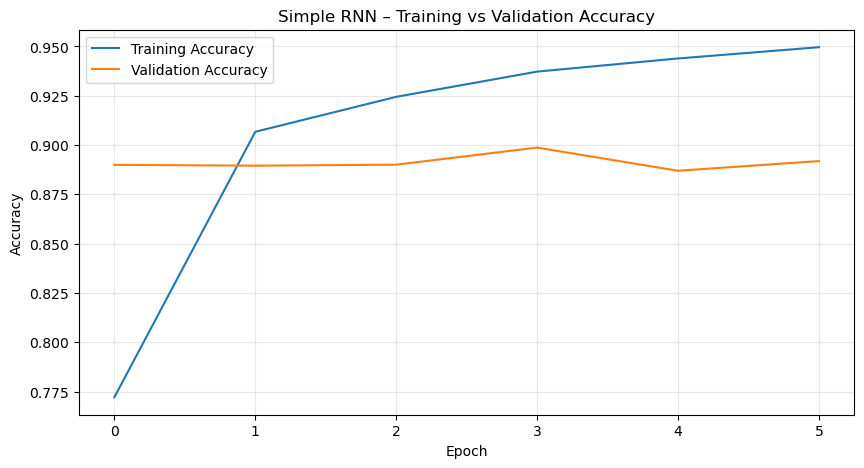

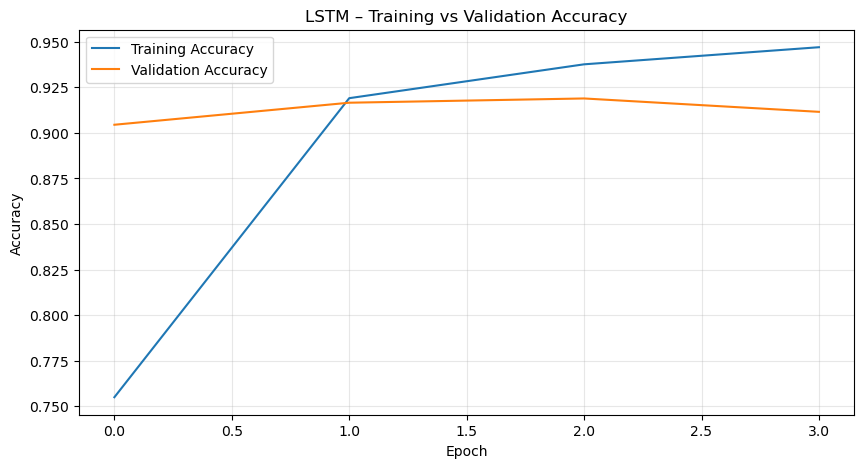

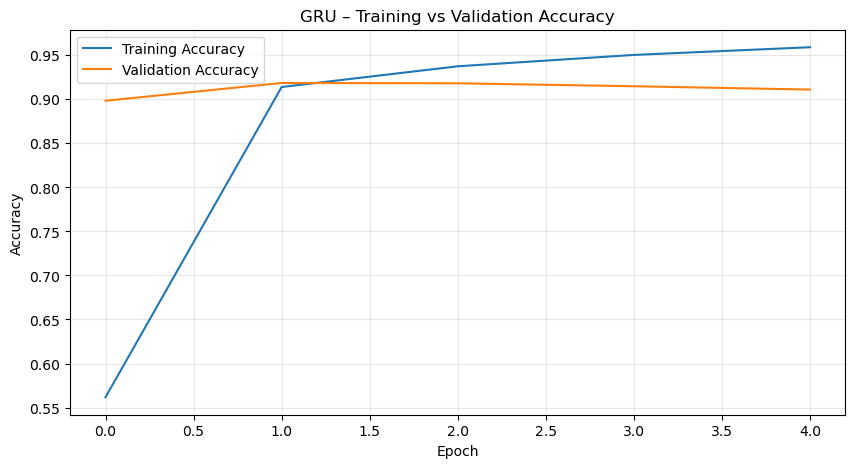

In [17]:
def plot_training_history(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_training_history(rnn_history, "Simple RNN – Training vs Validation Accuracy")
plot_training_history(lstm_history, "LSTM – Training vs Validation Accuracy")
plot_training_history(gru_history, "GRU – Training vs Validation Accuracy")


## 19. Evaluate All Models on the Test Dataset

In [18]:
models = {
    "Simple RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

histories = {
    "Simple RNN": rnn_history,
    "LSTM": lstm_history,
    "GRU": gru_history
}

training_times = {
    "Simple RNN": rnn_time,
    "LSTM": lstm_time,
    "GRU": gru_time
}

predictions = {}
results = []

for name, model in models.items():
    probabilities = model.predict(X_test_pad, batch_size=BATCH_SIZE, verbose=0)
    y_pred = np.argmax(probabilities, axis=1)
    predictions[name] = y_pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Training Time (s)": training_times[name],
        "Parameters": model.count_params()
    })

results_df = pd.DataFrame(results)
display(results_df.sort_values("F1-Score", ascending=False).reset_index(drop=True))


,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Parameters
0,GRU,0.915395,0.915656,0.915395,0.915103,129.600639,1305220
1,LSTM,0.914868,0.914892,0.914868,0.914697,121.531614,1313284
2,Simple RNN,0.892632,0.892775,0.892632,0.892150,95.586015,1288516


## 20. Detailed Classification Reports

In [19]:
target_names = ["World", "Sports", "Business", "Sci/Tech"]

for name, y_pred in predictions.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=target_names,
            digits=4,
            zero_division=0
        )
    )


Simple RNN
              precision    recall  f1-score   support

       World     0.8935    0.8879    0.8907      1900
      Sports     0.9425    0.9658    0.9540      1900
    Business     0.8843    0.8163    0.8489      1900
    Sci/Tech     0.8508    0.9005    0.8750      1900

    accuracy                         0.8926      7600
   macro avg     0.8928    0.8926    0.8921      7600
weighted avg     0.8928    0.8926    0.8921      7600

LSTM
              precision    recall  f1-score   support

       World     0.9344    0.8989    0.9163      1900
      Sports     0.9574    0.9826    0.9699      1900
    Business     0.8866    0.8721    0.8793      1900
    Sci/Tech     0.8812    0.9058    0.8933      1900

    accuracy                         0.9149      7600
   macro avg     0.9149    0.9149    0.9147      7600
weighted avg     0.9149    0.9149    0.9147      7600

GRU
              precision    recall  f1-score   support

       World     0.9403    0.8863    0.9125      1900
 

## 21. Overall Model Performance

In [20]:
baseline_row = pd.DataFrame([{
    "Model": "Majority Baseline",
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "F1-Score": baseline_f1,
    "Training Time (s)": np.nan,
    "Parameters": np.nan
}])

overall_results = pd.concat([baseline_row, results_df], ignore_index=True)

display(
    overall_results.sort_values(
        "F1-Score",
        ascending=False
    ).reset_index(drop=True)
)


,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Parameters
0,GRU,0.915395,0.915656,0.915395,0.915103,129.600639,1305220.0
1,LSTM,0.914868,0.914892,0.914868,0.914697,121.531614,1313284.0
2,Simple RNN,0.892632,0.892775,0.892632,0.892150,95.586015,1288516.0
3,Majority Baseline,0.250000,0.062500,0.250000,0.100000,NaN,NaN


## 22. Visual Comparison of Metrics

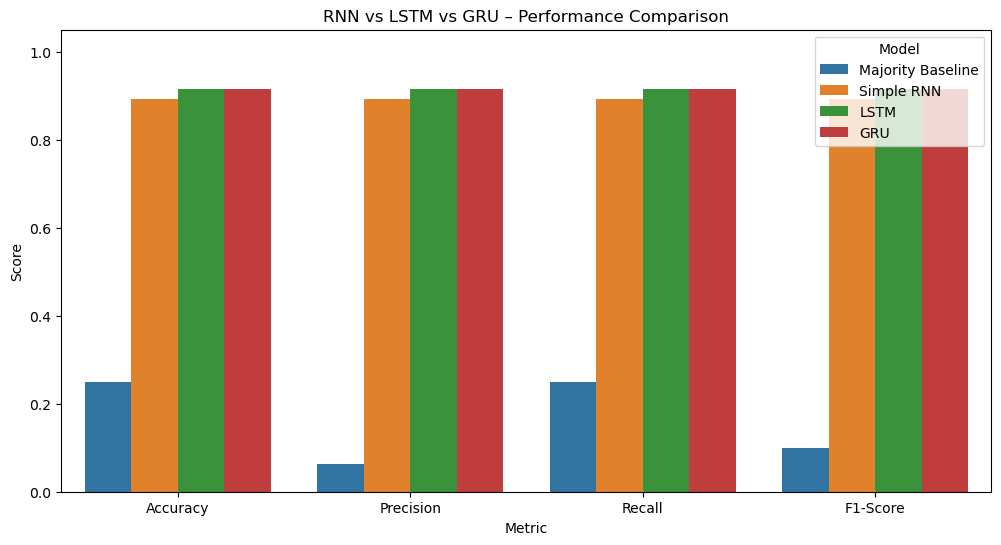

In [21]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score"]

plot_df = overall_results.melt(
    id_vars="Model",
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
plt.title("RNN vs LSTM vs GRU – Performance Comparison")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.show()


## 23. Confusion Matrices

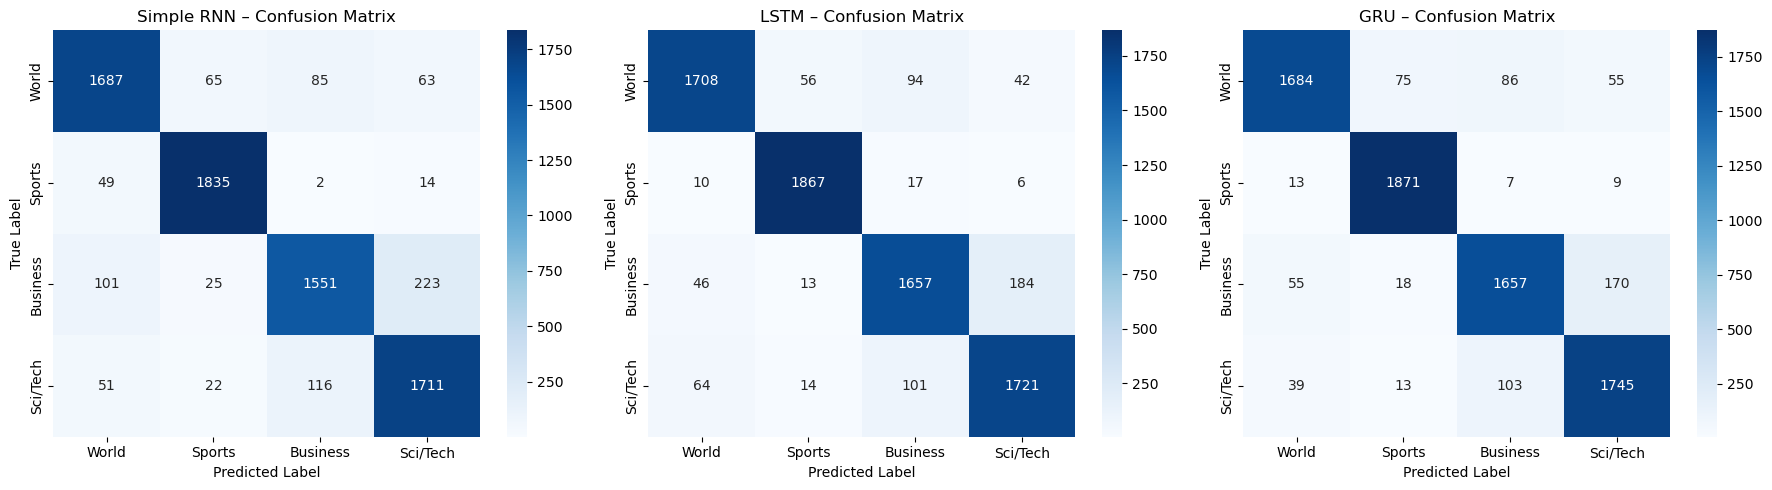

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names,
        ax=ax
    )

    ax.set_title(f"{name} – Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()


## 24. Model Complexity Comparison

In [23]:
complexity_df = results_df[
    ["Model", "Parameters", "Training Time (s)", "F1-Score"]
].copy()

complexity_df = complexity_df.sort_values(
    "F1-Score",
    ascending=False
).reset_index(drop=True)

display(complexity_df)


,Model,Parameters,Training Time (s),F1-Score
0,GRU,1305220,129.600639,0.915103
1,LSTM,1313284,121.531614,0.914697
2,Simple RNN,1288516,95.586015,0.892150


## 25. Select the Best Model

For a fair comparison, the neural-network models are ranked primarily using **macro F1-score** rather than accuracy alone.

Macro F1 gives equal importance to all four news categories.


In [24]:
best_model_row = results_df.loc[results_df["F1-Score"].idxmax()]

best_model_name = best_model_row["Model"]
best_f1 = best_model_row["F1-Score"]
best_accuracy = best_model_row["Accuracy"]

print("Best Model:", best_model_name)
print(f"Test Accuracy: {best_accuracy:.4f}")
print(f"Macro F1-score: {best_f1:.4f}")


Best Model: GRU
Test Accuracy: 0.9154
Macro F1-score: 0.9151


## 26. Custom News Article Prediction

The trained models can also be used to classify a new news article.

The same preprocessing, tokenizer, and padding configuration used during training must be applied to new text.


In [25]:
def predict_news(text, model):
    cleaned = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    probabilities = model.predict(padded, verbose=0)[0]
    predicted_class = int(np.argmax(probabilities))

    labels = ["World", "Sports", "Business", "Sci/Tech"]

    return labels[predicted_class], probabilities


sample_news = (
    "The national football team secured a dramatic victory in the final minutes of the match after scoring two goals in the second half. The win puts the team at the top of the tournament standings. "
)

print("News Article:")
print(sample_news)
print()

for name, model in models.items():
    label, probabilities = predict_news(sample_news, model)
    print(f"{name}: {label}")
    print("Probabilities:", np.round(probabilities, 4))
    print()


News Article:
The national football team secured a dramatic victory in the final minutes of the match after scoring two goals in the second half. The win puts the team at the top of the tournament standings. 

Simple RNN: Sports
Probabilities: [0.0105 0.985  0.0025 0.002 ]

LSTM: Sports
Probabilities: [0.013  0.9842 0.0015 0.0012]

GRU: Sports
Probabilities: [7.400e-03 9.916e-01 6.000e-04 4.000e-04]



## 27. Architecture Comparison

| Model | Main Mechanism | Strength | Limitation |
|---|---|---|---|
| Simple RNN | Recurrent hidden state | Simple and fast | Can struggle with long-term dependencies |
| LSTM | Input, forget and output gates | Strong memory handling | More parameters |
| GRU | Update and reset gates | Efficient gated architecture | Slightly less expressive than LSTM in some tasks |

The final model should be selected from the **actual test results**, rather than assuming that one architecture is always best.


## 28. Final Analysis

After training and evaluating all three architectures, compare them using:

1. **Test Accuracy** – overall percentage of correct predictions.
2. **Macro Precision** – average precision across the four categories.
3. **Macro Recall** – average recall across the four categories.
4. **Macro F1-score** – balanced measure of precision and recall.
5. **Training Time** – computational cost.
6. **Parameter Count** – model complexity.

### Expected Interpretation

- The **Simple RNN** provides a basic recurrent baseline.
- **LSTM** uses gated memory and can better handle long-term dependencies.
- **GRU** provides gated memory with a simpler architecture than LSTM.
- Since AG News is balanced, accuracy is meaningful, but macro F1 is also reported to ensure every class is considered equally.
- The majority baseline should be close to **25% accuracy**, while a useful neural model should substantially outperform it.

> **Important:** The final conclusion should be based on the numerical results produced when the notebook is executed.


# Conclusion

This experiment demonstrated multi-class text classification using three recurrent neural network architectures: **Simple RNN, LSTM, and GRU**.

The complete workflow included:

- Dataset loading and exploration
- Text preprocessing
- Stratified train-validation split
- Tokenization and sequence padding
- Majority-class baseline
- Simple RNN implementation
- LSTM implementation
- GRU implementation
- Model training with early stopping
- Test-set evaluation
- Accuracy, precision, recall and F1-score comparison
- Confusion matrix analysis
- Training-time and parameter comparison
- Custom news article prediction

The best architecture is selected based on the **actual macro F1-score and overall test performance** obtained from the experiment.

**End of Assignment**
